<a href="https://colab.research.google.com/github/nilnil47/simple-committee-machine/blob/main/simple_commette_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Minimal Teacher-Student Model (Knowledge Distillation) Implementation

Knowledge Distillation involves training a smaller 'Student' model to mimic the behavior of a pre-trained, larger 'Teacher' model.

### Teacher: Hermite Polynomial $He_3(w_* \cdot x)$

In this setup, the teacher is not a neural network but a fixed direction $w_*$. The target output is the third Hermite polynomial $He_3(z) = z^3 - 3z$ applied to the projection of $x$ onto $w_*$.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt

# Parameters
dimension = 10
batch_size = 256  # Increased for stability
n_hidden = 32

# 1. Define the Teacher (Fixed Direction w_*)
w_star = torch.randn(dimension, 1)
w_star = w_star / torch.norm(w_star)

def hermite_teacher(x, w):
    z = torch.matmul(x, w)
    # He_3(z) = z^3 - 3z
    return (z**3 - 3*z).squeeze()

# 2. Define the Committee Student Model
class CommitteeStudent(nn.Module):
    def __init__(self, d: int, n_hidden: int) -> None:
        super().__init__()
        self.readout_scale = 1.0 / math.sqrt(n_hidden)
        self.W = nn.Parameter(torch.empty(n_hidden, d))
        nn.init.normal_(self.W, mean=0.0, std=1.0 / math.sqrt(d))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = torch.erf(x @ self.W.T)
        return self.readout_scale * h.sum(dim=-1)

student_hermite = CommitteeStudent(dimension, n_hidden)
# Using a standard learning rate for Adam
optimizer = optim.Adam(student_hermite.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [14]:
from torch.utils.data import TensorDataset, DataLoader

# 2.5 Create a Predefined Dataset
num_samples = 100
x_data = torch.randn(num_samples, dimension)
with torch.no_grad():
    y_data = hermite_teacher(x_data, w_star)

dataset = TensorDataset(x_data, y_data)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Starting training on predefined dataset...
Epoch [10/1000], Smoothed Loss: 1.0305
Epoch [20/1000], Smoothed Loss: 1.0089
Epoch [30/1000], Smoothed Loss: 0.9723
Epoch [40/1000], Smoothed Loss: 0.9301
Epoch [50/1000], Smoothed Loss: 0.8876
Epoch [60/1000], Smoothed Loss: 0.8473
Epoch [70/1000], Smoothed Loss: 0.8099
Epoch [80/1000], Smoothed Loss: 0.7756
Epoch [90/1000], Smoothed Loss: 0.7443
Epoch [100/1000], Smoothed Loss: 0.7157
Epoch [110/1000], Smoothed Loss: 0.6895
Epoch [120/1000], Smoothed Loss: 0.6654
Epoch [130/1000], Smoothed Loss: 0.6433
Epoch [140/1000], Smoothed Loss: 0.6230
Epoch [150/1000], Smoothed Loss: 0.6041
Epoch [160/1000], Smoothed Loss: 0.5867
Epoch [170/1000], Smoothed Loss: 0.5705
Epoch [180/1000], Smoothed Loss: 0.5554
Epoch [190/1000], Smoothed Loss: 0.5413
Epoch [200/1000], Smoothed Loss: 0.5280
Epoch [210/1000], Smoothed Loss: 0.5156
Epoch [220/1000], Smoothed Loss: 0.5038
Epoch [230/1000], Smoothed Loss: 0.4928
Epoch [240/1000], Smoothed Loss: 0.4823
Epoch 

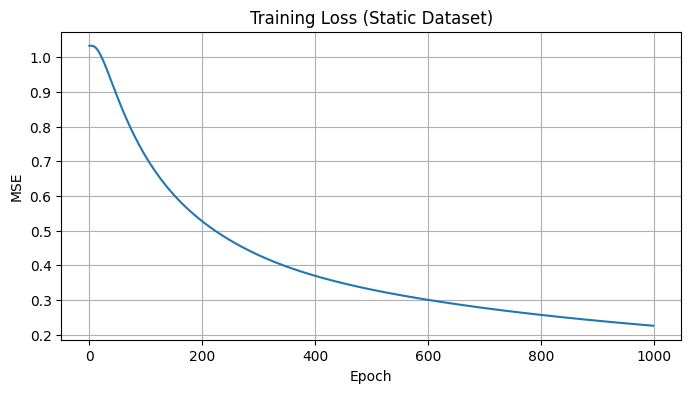

In [15]:
# 3. Updated Training Loop with DataLoader
train_epochs = 1000  # Number of full passes over the dataset
smooth_loss = []
running_loss = 0.0

print(f"Starting training on predefined dataset...")
for epoch in range(train_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        y_pred = student_hermite(x_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Average loss for the epoch
    avg_epoch_loss = epoch_loss / len(train_loader)

    if epoch == 0:
        running_loss = avg_epoch_loss
    else:
        running_loss = 0.9 * running_loss + 0.1 * avg_epoch_loss

    smooth_loss.append(running_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{train_epochs}], Smoothed Loss: {running_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(smooth_loss)
plt.title("Training Loss (Static Dataset)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

Starting GD training...
Epoch [200/2000], Smoothed Loss: 4.2458
Epoch [400/2000], Smoothed Loss: 6.1690
Epoch [600/2000], Smoothed Loss: 4.9038
Epoch [800/2000], Smoothed Loss: 4.2976
Epoch [1000/2000], Smoothed Loss: 4.5641
Epoch [1200/2000], Smoothed Loss: 5.2673
Epoch [1400/2000], Smoothed Loss: 5.3246
Epoch [1600/2000], Smoothed Loss: 4.4443
Epoch [1800/2000], Smoothed Loss: 5.3850
Epoch [2000/2000], Smoothed Loss: 4.4599


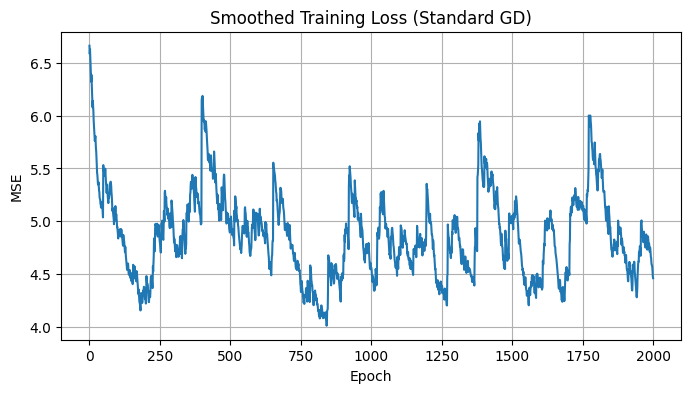

In [9]:
# 3. Stabilized Training Loop
train_epochs = 2000
smooth_loss = []
running_loss = 0.0

print(f"Starting GD training...")
for epoch in range(train_epochs):
    x_train = torch.randn(batch_size, dimension)
    with torch.no_grad():
        y_teacher = hermite_teacher(x_train, w_star)

    y_student = student_hermite(x_train)
    loss = criterion(y_student, y_teacher)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track moving average to smooth out stochastic spikes
    if epoch == 0:
        running_loss = loss.item()
    else:
        running_loss = 0.98 * running_loss + 0.02 * loss.item()

    smooth_loss.append(running_loss)

    if (epoch + 1) % 200 == 0:
        print(f"Epoch [{epoch+1}/{train_epochs}], Smoothed Loss: {running_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(smooth_loss)
plt.title("Smoothed Training Loss (Standard GD)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

In [3]:
### Evaluate on Test Loss
# Generate fresh data that the model hasn't seen
x_test = torch.randn(1000, dimension)
with torch.no_grad():
    y_test_teacher = hermite_teacher(x_test, w_star)
    y_test_student = student_hermite(x_test)
    test_loss = criterion(y_test_student, y_test_teacher)

print(f"Final Training Loss: {loss.item():.4f}")
print(f"Test Loss (Generalization): {test_loss.item():.4f}")

Final Training Loss: 2.2081
Test Loss (Generalization): 4.6935


In [4]:
import torch
import math

# 1. Theoretical Baseline: Variance of He_3(z) where z ~ N(0,1) is 3! = 6
theoretical_variance = math.factorial(3)

# 2. Empirical Baseline: Calculate variance from a large sample
x_large = torch.randn(10000, dimension)
with torch.no_grad():
    y_large = hermite_teacher(x_large, w_star)
    empirical_variance = torch.var(y_large).item()

print(f"--- Theoretical Benchmarks ---")
print(f"Theoretical Teacher Variance (Baseline MSE): {theoretical_variance}")
print(f"Empirical Teacher Variance: {empirical_variance:.4f}")
print(f"Current Student Test MSE: {test_loss.item():.4f}")

# Fraction of Variance Unexplained (FVU)
fvu = test_loss.item() / empirical_variance
print(f"\nFraction of Variance Unexplained: {fvu:.4f}")
print(f"Model Accuracy (1 - FVU): {(1 - fvu)*100:.2f}%")

--- Theoretical Benchmarks ---
Theoretical Teacher Variance (Baseline MSE): 6
Empirical Teacher Variance: 6.5645
Current Student Test MSE: 4.6935

Fraction of Variance Unexplained: 0.7150
Model Accuracy (1 - FVU): 28.50%


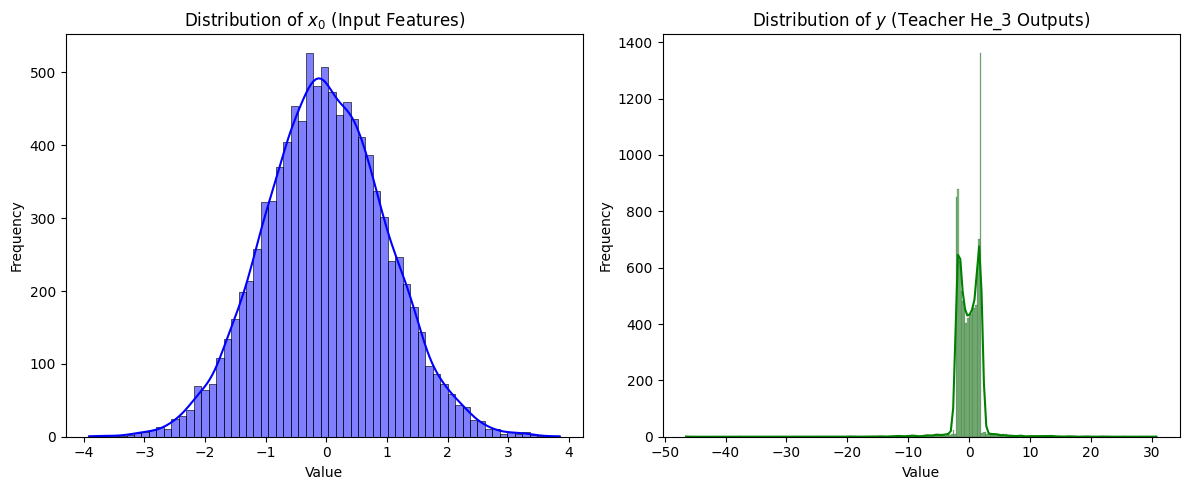

Mean of x: 0.0007 (Expected: 0)
Std of x: 1.0000 (Expected: 1)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distributions
plt.figure(figsize=(12, 5))

# 1. Feature Distribution (First dimension)
plt.subplot(1, 2, 1)
sns.histplot(x_data[:, 0].numpy(), kde=True, color='blue')
plt.title('Distribution of $x_0$ (Input Features)')
plt.xlabel('Value')
plt.ylabel('Frequency')

# 2. Target Distribution (Teacher Outputs)
plt.subplot(1, 2, 2)
sns.histplot(y_data.numpy(), kde=True, color='green')
plt.title('Distribution of $y$ (Teacher He_3 Outputs)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Mean of x: {x_data.mean().item():.4f} (Expected: 0)")
print(f"Std of x: {x_data.std().item():.4f} (Expected: 1)")